# Analysis for Label Noise Method

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing_extensions import *
from sentence_transformers import SentenceTransformer

In [50]:
class MlpMapper(nn.Module):
	def __init__(self, input_dim: int, intermediate_dims: List, output_dim: int, use_bias: bool = True, logit_scale: float = 100.0):
		super().__init__()
		self.input_dim = input_dim
		self.intermediate_dims = intermediate_dims # list of ints
		self.output_dim = output_dim
		self.num_layers = len(intermediate_dims) + 1

		self.layers = []
		current_dim = input_dim
		next_dims = intermediate_dims + [output_dim]

		if logit_scale < 0:
			self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
		else:
			self.logit_scale = torch.tensor(np.log(logit_scale))

		for i in range(self.num_layers):
			self.layers.append(nn.Linear(current_dim, next_dims[i], bias=use_bias))
			current_dim = next_dims[i]

			if i != self.num_layers - 1:
				self.layers.append(nn.GELU())

		self.layers = nn.Sequential(*self.layers)

	def forward(self, x):
		x = self.layers(x)
		return F.normalize(x, dim=-1)


## Cifar-10

In [51]:
image_embeddings = np.load("embeddings/cifar10/radius_analysis_embeddings.npy", allow_pickle=True)
image_embeddings = image_embeddings.item()

class_embeddings = np.load("embeddings/cifar10/class_embeddings_over_epochs.npy", allow_pickle=True)
class_embeddings = class_embeddings.item()


In [52]:
all_image_embeddings = np.concatenate([
    v for v in image_embeddings["image"].values()
], axis=0)

all_text_embeddings = np.concatenate([
    v for v in class_embeddings.values()
], axis=0)
print(all_text_embeddings.shape)


(100, 384)


In [53]:
class_index = 0

pca = PCA(n_components=2)
pca.fit(all_image_embeddings)
image_embeddings_2d = pca.transform(image_embeddings["image"][class_index])
all_text_embeddings_2d = pca.transform(all_text_embeddings)

In [54]:
image_centroid = pca.transform(image_embeddings["image"][class_index].mean(axis=0).reshape(1, -1))
image_centroid

array([[0.21023571, 0.0955553 ]], dtype=float32)

In [55]:
with torch.no_grad():
    tmp_mapper = MlpMapper(768, [], 384)
    tmp_te = SentenceTransformer("sentence-t5-base")
    emb = tmp_te.encode(["a photo of a airplane"])
    ep0_text_embedding = tmp_mapper(torch.from_numpy(emb))

ep0_temb_2d = pca.transform(ep0_text_embedding)
ep0_temb_2d

array([[-0.04635246,  0.08011671]])

### Un-normalized, Euclidean

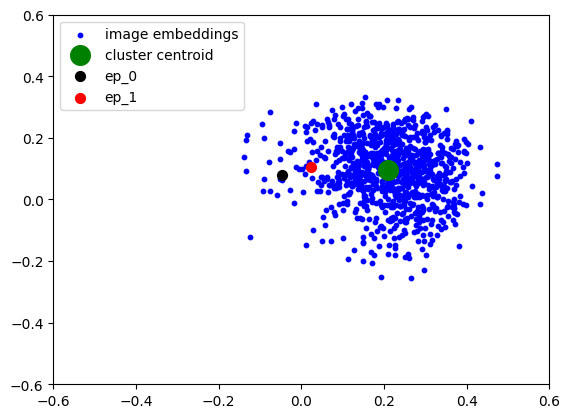

In [56]:
plt.scatter(image_embeddings_2d[:, 0], image_embeddings_2d[:, 1], label="image embeddings", c="blue", s=10)
plt.scatter(image_centroid[:, 0], image_centroid[:, 1], c="green", s=200, label="cluster centroid")

plt.scatter(ep0_temb_2d[0, 0], ep0_temb_2d[0, 1], label=f"ep_0", c="black", s=50)
plt.scatter(all_text_embeddings_2d[0, 0], all_text_embeddings_2d[0, 1], label=f"ep_1", c="red", s=50)
plt.xlim([-0.6, 0.6])
plt.ylim([-0.6, 0.6])
plt.legend()
plt.show()

### Normalized, Cosine

In [57]:
# Normalize all_text_embeddings_2d
all_text_embeddings_2d = all_text_embeddings_2d / np.linalg.norm(all_text_embeddings_2d, axis=-1, keepdims=True)

# Normalize image_embeddings_2d
image_embeddings_2d = image_embeddings_2d / np.linalg.norm(image_embeddings_2d, axis=-1, keepdims=True)

image_centroid /= np.linalg.norm(image_centroid, axis=-1, keepdims=True)
ep0_temb_2d /= np.linalg.norm(ep0_temb_2d, axis=-1, keepdims=True)

In [58]:
print(image_centroid, ep0_temb_2d)

[[0.9103769 0.41378  ]] [[-0.50078626  0.86557098]]


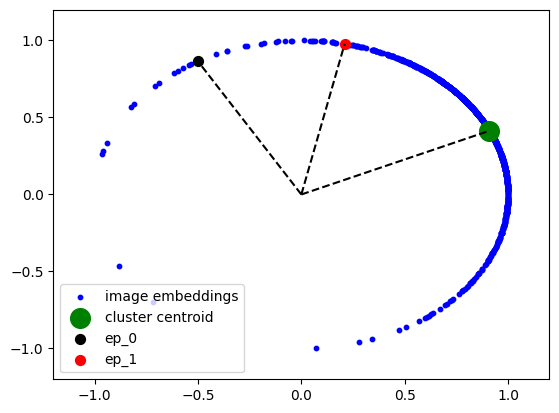

In [59]:
plt.scatter(image_embeddings_2d[:, 0], image_embeddings_2d[:, 1], label="image embeddings", c="blue", s=10)
plt.scatter(image_centroid[:, 0], image_centroid[:, 1], c="green", s=200, label="cluster centroid")
plt.plot([0.0, image_centroid[:, 0].item()], [0.0, image_centroid[:, 1].item()], c="black", linestyle="--")

j = 0
plt.scatter(ep0_temb_2d[0, 0], ep0_temb_2d[0, 1], label=f"ep_0", c="black", s=50)
plt.plot([0.0, ep0_temb_2d[j, 0]], [0.0, ep0_temb_2d[j, 1]], c="black", linestyle="--")

plt.scatter(all_text_embeddings_2d[j, 0], all_text_embeddings_2d[j, 1], label=f"ep_1", c="red", s=50)
plt.plot([0.0, all_text_embeddings_2d[j, 0]], [0.0, all_text_embeddings_2d[j, 1]], c="black", linestyle="--")

plt.xlim([-1.2, 1.2])
plt.ylim([-1.2, 1.2])
plt.legend()
plt.show()

## ImageNet1k

In [60]:
image_embeddings = np.load("embeddings/imagenet/radius_analysis_embeddings.npy", allow_pickle=True)
image_embeddings = image_embeddings.item()

class_embeddings = np.load("embeddings/imagenet/class_embeddings_over_epochs.npy", allow_pickle=True)
class_embeddings = class_embeddings.item()

In [61]:
all_image_embeddings = np.concatenate([
    v for v in image_embeddings["image"].values()
], axis=0)

all_text_embeddings = np.concatenate([
    v for v in class_embeddings.values()
], axis=0)
print(all_text_embeddings.shape)

(10000, 384)


In [62]:
class_index = 0

pca = PCA(n_components=2)
pca.fit(all_image_embeddings)
image_embeddings_2d = pca.transform(image_embeddings["image"][class_index])
all_text_embeddings_2d = pca.transform(all_text_embeddings)

In [63]:
image_centroid = pca.transform(image_embeddings["image"][class_index].mean(axis=0).reshape(1, -1))
image_centroid

array([[-0.07874291, -0.04038155]], dtype=float32)

In [64]:
with torch.no_grad():
    tmp_mapper = MlpMapper(768, [], 384)
    tmp_te = SentenceTransformer("sentence-t5-base")
    emb = tmp_te.encode(["a photo of a tench"])
    ep0_text_embedding = tmp_mapper(torch.from_numpy(emb))

ep0_temb_2d = pca.transform(ep0_text_embedding)
ep0_temb_2d

array([[-0.06850769, -0.01814839]])

### Un-normalised, Euclidean

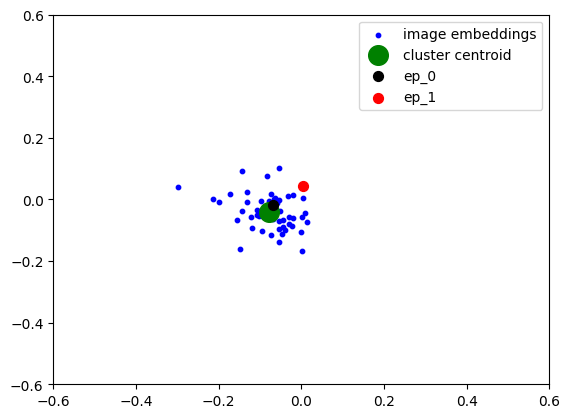

In [65]:
plt.scatter(image_embeddings_2d[:, 0], image_embeddings_2d[:, 1], label="image embeddings", c="blue", s=10)
plt.scatter(image_centroid[:, 0], image_centroid[:, 1], c="green", s=200, label="cluster centroid")

plt.scatter(ep0_temb_2d[0, 0], ep0_temb_2d[0, 1], label=f"ep_0", c="black", s=50)
plt.scatter(all_text_embeddings_2d[0, 0], all_text_embeddings_2d[0, 1], label=f"ep_1", c="red", s=50)
plt.xlim([-0.6, 0.6])
plt.ylim([-0.6, 0.6])
plt.legend()
plt.show()

### Normalised, Cosine

In [66]:
# Normalize all_text_embeddings_2d
all_text_embeddings_2d = all_text_embeddings_2d / np.linalg.norm(all_text_embeddings_2d, axis=-1, keepdims=True)

# Normalize image_embeddings_2d
image_embeddings_2d = image_embeddings_2d / np.linalg.norm(image_embeddings_2d, axis=-1, keepdims=True)

image_centroid /= np.linalg.norm(image_centroid, axis=-1, keepdims=True)
ep0_temb_2d /= np.linalg.norm(ep0_temb_2d, axis=-1, keepdims=True)

In [67]:
print(image_centroid, ep0_temb_2d)

[[-0.88981485 -0.45632175]] [[-0.96665634 -0.25607718]]


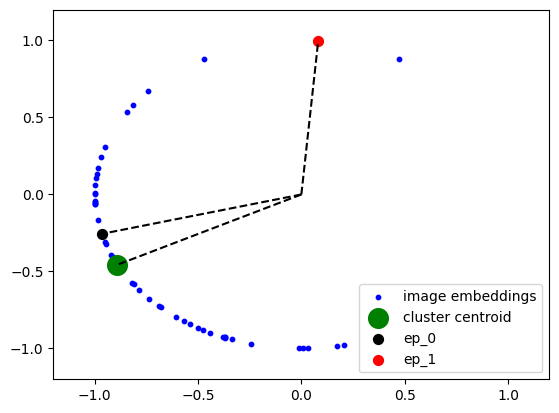

In [68]:
plt.scatter(image_embeddings_2d[:, 0], image_embeddings_2d[:, 1], label="image embeddings", c="blue", s=10)
plt.scatter(image_centroid[:, 0], image_centroid[:, 1], c="green", s=200, label="cluster centroid")
plt.plot([0.0, image_centroid[:, 0].item()], [0.0, image_centroid[:, 1].item()], c="black", linestyle="--")

j = 0
plt.scatter(ep0_temb_2d[0, 0], ep0_temb_2d[0, 1], label=f"ep_0", c="black", s=50)
plt.plot([0.0, ep0_temb_2d[j, 0]], [0.0, ep0_temb_2d[j, 1]], c="black", linestyle="--")

plt.scatter(all_text_embeddings_2d[j, 0], all_text_embeddings_2d[j, 1], label=f"ep_1", c="red", s=50)
plt.plot([0.0, all_text_embeddings_2d[j, 0]], [0.0, all_text_embeddings_2d[j, 1]], c="black", linestyle="--")

plt.xlim([-1.2, 1.2])
plt.ylim([-1.2, 1.2])
plt.legend()
plt.show()